In [45]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


In [46]:
data = yf.download(tickers = 'QQQ', period ='1y', interval ='1h')
data

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
2021-10-15 09:30:00-04:00,367.880005,368.160004,366.820007,366.936890,366.936890,9299421
2021-10-15 10:30:00-04:00,366.940002,368.630005,366.940002,368.260010,368.260010,4518931
2021-10-15 11:30:00-04:00,368.250000,368.409912,367.125000,367.799988,367.799988,6898740
2021-10-15 12:30:00-04:00,367.799988,368.140015,367.579987,367.799988,367.799988,3794769
2021-10-15 13:30:00-04:00,367.809998,368.528015,367.804993,368.399994,368.399994,2355215
...,...,...,...,...,...,...
2022-10-14 12:30:00-04:00,262.769989,263.515015,261.829987,262.549988,262.549988,6513897
2022-10-14 13:30:00-04:00,262.540009,263.250000,261.260010,261.750000,261.750000,5179900
2022-10-14 14:30:00-04:00,261.720001,262.450012,261.010010,261.679993,261.679993,5896436
2022-10-14 15:30:00-04:00,261.690002,262.191193,260.140015,260.630005,260.630005,8922831


In [49]:
def SMA(data):
    data['SMA5'] = data.Close.rolling(5).mean()
    data['SMA20'] = data.Close.rolling(20).mean()
    
data.head(SMA(data))    

,Open,High,Low,Close,Adj Close,Volume,SMA5,SMA20
2021-10-15 09:30:00-04:00,367.880005,368.160004,366.820007,366.936890,366.936890,9299421,NaN,NaN
2021-10-15 10:30:00-04:00,366.940002,368.630005,366.940002,368.260010,368.260010,4518931,NaN,NaN
2021-10-15 11:30:00-04:00,368.250000,368.409912,367.125000,367.799988,367.799988,6898740,NaN,NaN
2021-10-15 12:30:00-04:00,367.799988,368.140015,367.579987,367.799988,367.799988,3794769,NaN,NaN
2021-10-15 13:30:00-04:00,367.809998,368.528015,367.804993,368.399994,368.399994,2355215,367.839374,NaN
...,...,...,...,...,...,...,...,...
2022-10-14 12:30:00-04:00,262.769989,263.515015,261.829987,262.549988,262.549988,6513897,264.758014,264.250551
2022-10-14 13:30:00-04:00,262.540009,263.250000,261.260010,261.750000,261.750000,5179900,263.360016,264.232106
2022-10-14 14:30:00-04:00,261.720001,262.450012,261.010010,261.679993,261.679993,5896436,262.728015,264.171605
2022-10-14 15:30:00-04:00,261.690002,262.191193,260.140015,260.630005,260.630005,8922831,261.880017,264.032330


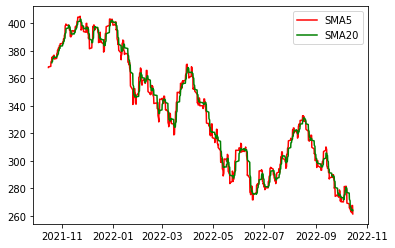

In [50]:
plt.plot(data.SMA5, label='SMA5', color='red')
plt.plot(data.SMA20, label='SMA20', color='green')

plt.legend()
plt.show()

In [52]:
Buy, Sell = [], []

for i in range (2,len(data)):

    if data.SMA5.iloc[i] > data.SMA20.iloc[i] and data.SMA5.iloc[i-1] < data.SMA20.iloc[i-1]:
        Buy.append(i)
        
    if data.SMA5.iloc[i] < data.SMA20.iloc[i]  and data.SMA5.iloc[i-1] > data.SMA20.iloc[i-1]: 
        Sell.append(i)

In [53]:
Buy

[45,
 142,
 210,
 223,
 248,
 297,
 323,
 362,
 381,
 418,
 488,
 507,
 555,
 588,
 634,
 658,
 693,
 703,
 705,
 722,
 771,
 818,
 868,
 888,
 900,
 938,
 959,
 1014,
 1056,
 1072,
 1105,
 1128,
 1169,
 1187,
 1252,
 1306,
 1364,
 1421,
 1434,
 1507,
 1552,
 1569,
 1627,
 1636,
 1671,
 1695,
 1751]

In [55]:
Realbuys = [i+1 for i in Buy]
Realsells = [i+1 for i in Sell]

In [57]:
Buyprices = data.Open.iloc[Realbuys]
Sellprices = data.Open.iloc[Realsells]

In [58]:
if Sellprices.index[0] < Buyprices.index[0]:
    Sellprices = Sellprices.drop(Sellprices.index[0])
    
elif Buyprices.index[-1] > Sellprices.index[-1]:
    Buyprices = Buyprices.drop(Sellprices.index[-1])    

In [59]:
profitsrel = []

for i in range(len(Buyprices)):
    profitsrel.append((Sellprices[i]-Buyprices[i])/Buyprices[i])

In [60]:
profit = sum(profitsrel)
print (profit)

-0.02874486863252979
